# Statistical Testing for A/B Experiment

## Introduction
In this notebook, we perform formal statistical hypothesis testing on the results of our A/B experiment. The exploratory data analysis (EDA) phase provided directional insights, but hypothesis testing is required to determine if the observed differences between the control (old page) and treatment (new page) groups are statistically significant or merely due to random variance.

Statistical significance helps us ensure that the findings are robust and can be reliably expected when deployed to the broader user base.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for visualizations
sns.set_theme(style='whitegrid', palette='muted')
import warnings
warnings.filterwarnings('ignore')

## Load Processed Data

In [ ]:
# Load data from processed directory
df = pd.read_csv('../data/processed/cleaned_data.csv')
exp_summary = pd.read_csv('../data/processed/experiment_summary.csv')

df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


## Display Experiment Summary

In [ ]:
# Display the aggregated summary from previous processing
display(exp_summary)

,group,users,conversion_rate_pct,arpu,avg_session_duration,avg_pages_visited
0,control,146926,11.872643,4.452769,5.003684,4.015327
1,treatment,147552,17.948926,6.763299,5.000594,4.023754
2,overall,294478,14.917243,5.610490,5.002136,4.019550


## State Hypotheses

We are evaluating whether the treatment group (new landing page) resulted in a higher conversion rate than the control group (old landing page). Let $p_{control}$ be the conversion rate of the control group and $p_{treatment}$ be the conversion rate of the treatment group.

*   **Null Hypothesis ($H_0$):** The new page performs the same or worse than the old page. $$p_{treatment} - p_{control} \le 0$$
*   **Alternative Hypothesis ($H_1$):** The new page performs strictly better than the old page. $$p_{treatment} - p_{control} > 0$$

## Calculate Basic Metrics

In [ ]:
# Filter groups
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

# Total Users
n_control = control.shape[0]
n_treatment = treatment.shape[0]
total_users = n_control + n_treatment

# Total Conversions
conv_control = control['converted'].sum()
conv_treatment = treatment['converted'].sum()
total_conversions = conv_control + conv_treatment

# Conversion Rates
cr_control = conv_control / n_control
cr_treatment = conv_treatment / n_treatment

# Lift
lift = (cr_treatment - cr_control) / cr_control

print(f"Total Users: {total_users}")
print(f"Total Conversions: {total_conversions}")
print(f"Control Conversion Rate: {cr_control:.4%}")
print(f"Treatment Conversion Rate: {cr_treatment:.4%}")
print(f"Conversion Lift: {lift:.4%}")

Total Users: 294478
Total Conversions: 43928
Control Conversion Rate: 11.8726%
Treatment Conversion Rate: 17.9489%
Conversion Lift: 51.1789%


## Two-Proportion Z-Test

To test our hypothesis regarding proportions, we use the Two-Proportion Z-Test. This test is appropriate because our sample size is very large ($n > 30$), and the observations are independent.

**Assumptions:**
*   Independent observations.
*   Random assignment.
*   Sufficiently large sample size for normal approximation.

**Formula:**
$$Z = \frac{\hat{p}_t - \hat{p}_c}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_t} + \frac{1}{n_c})}}$$

In [ ]:
successes = np.array([conv_treatment, conv_control])
nobs = np.array([n_treatment, n_control])

# Perform Z-test (one-tailed alternative: treatment > control)
z_stat, p_value = proportions_ztest(count=successes, nobs=nobs, alternative='larger')

print(f"Z-score: {z_stat:.4f}")
print(f"P-value: {p_value:.4e}")

Z-score: 46.2773
P-value: 0.0000e+00


## Chi-Square Test

We also use a Chi-Square test of independence to determine if there is a significant association between the group assignment and conversion status.

In [ ]:
# Create Contingency Table
contingency_table = pd.crosstab(df['group'], df['converted'])
print("Contingency Table:\n", contingency_table, "\n")

# Perform Chi-Square Test
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {chi2_p:.4e}")

Contingency Table:
 converted       0      1
group                   
control    129482  17444
treatment  121068  26484 

Chi-Square Statistic: 2141.1135
P-value: 0.0000e+00


## Confidence Interval

The 95% confidence interval gives us a range within which we expect the true difference in conversion rates to fall. If the lower bound is greater than 0, it supports rejecting $H_0$.

In [ ]:
# Calculate Confidence Intervals for proportions
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method='normal')
ci_control = proportion_confint(conv_control, n_control, alpha=0.05, method='normal')

# Calculate CI for the difference (Treatment - Control)
diff = cr_treatment - cr_control
se_diff = np.sqrt((cr_treatment*(1-cr_treatment)/n_treatment) + (cr_control*(1-cr_control)/n_control))
z_crit = stats.norm.ppf(0.975) # 95% Two-sided equivalent for error margin
margin_error = z_crit * se_diff

ci_diff_lower = diff - margin_error
ci_diff_upper = diff + margin_error

print(f"95% Confidence Interval for Difference: [{ci_diff_lower:.4%}, {ci_diff_upper:.4%}]")

95% Confidence Interval for Difference: [5.8200%, 6.3326%]


## Effect Size

We calculate Cohen's $h$ to measure the magnitude of the difference between two proportions. 

*   h < 0.2: Small effect
*   h \approx 0.5: Medium effect
*   h > 0.8: Large effect

In [ ]:
# Calculate Cohen's h
h = 2 * np.arcsin(np.sqrt(cr_treatment)) - 2 * np.arcsin(np.sqrt(cr_control))
print(f"Cohen's h (Effect Size): {h:.4f}")

Cohen's h (Effect Size): 0.1714


## Statistical Significance

*   **Alpha ($\alpha$):** 0.05 (Our threshold for rejecting the null hypothesis)
*   **P-value:** From the tests above. If $p \le \alpha$, the result is statistically significant.
*   **Type I Error:** Falsely rejecting the null hypothesis (False Positive).
*   **Type II Error:** Failing to reject a false null hypothesis (False Negative).
*   **Practical Significance:** Even if a result is statistically significant, we must evaluate if the effect size and absolute lift justify the business cost of deploying the change.

## Secondary Metrics

We will evaluate `purchase_amount` and `session_duration` using the Independent Sample T-Test.

In [ ]:
if 'purchase_amount' in df.columns and 'session_duration' in df.columns:
    t_stat_rev, p_val_rev = stats.ttest_ind(treatment['purchase_amount'], control['purchase_amount'], equal_var=False)
    t_stat_sess, p_val_sess = stats.ttest_ind(treatment['session_duration'], control['session_duration'], equal_var=False)
    
    print(f"Purchase Amount T-Test -> T-stat: {t_stat_rev:.4f}, P-value: {p_val_rev:.4e}")
    print(f"Session Duration T-Test -> T-stat: {t_stat_sess:.4f}, P-value: {p_val_sess:.4e}")

Purchase Amount T-Test -> T-stat: 40.7382, P-value: 0.0000e+00
Session Duration T-Test -> T-stat: -0.4233, P-value: 6.7204e-01


## Visualizations

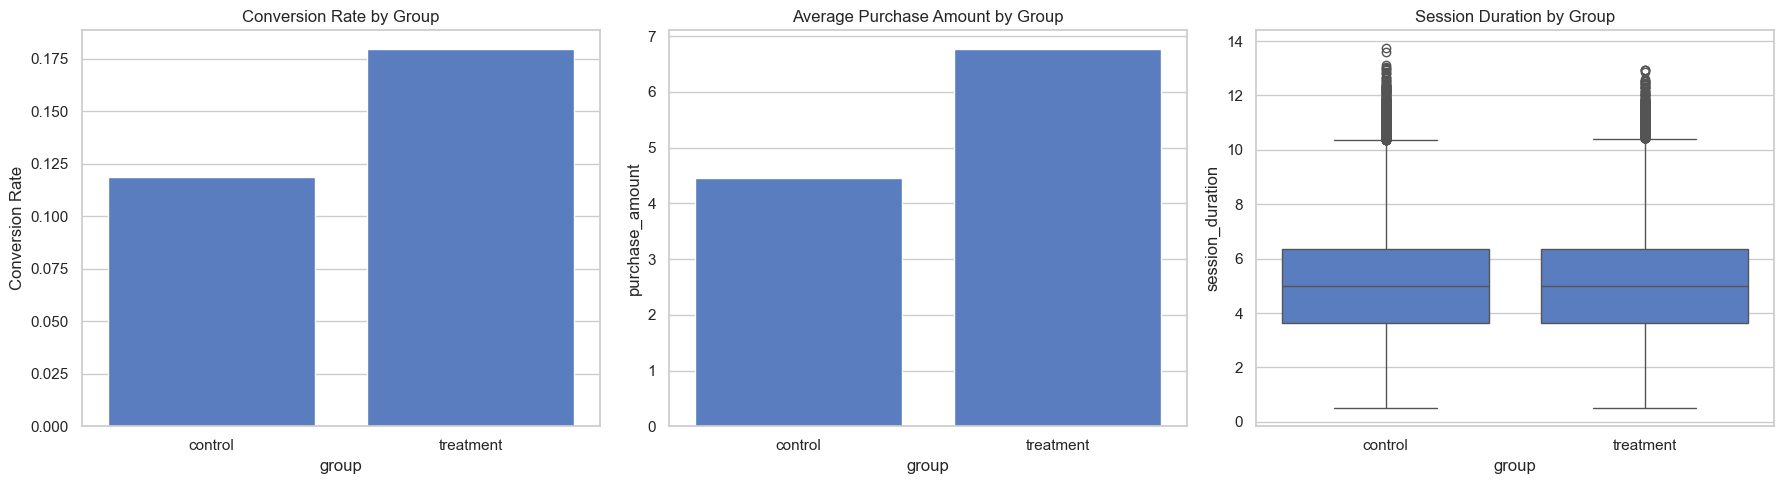

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Conversion comparison
sns.barplot(x='group', y='converted', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate')

# 2. Purchase comparison
if 'purchase_amount' in df.columns:
    sns.barplot(x='group', y='purchase_amount', data=df, ax=axes[1], errorbar=None)
    axes[1].set_title('Average Purchase Amount by Group')

# 3. Session Duration
if 'session_duration' in df.columns:
    sns.boxplot(x='group', y='session_duration', data=df, ax=axes[2])
    axes[2].set_title('Session Duration by Group')

plt.tight_layout()
plt.show()

## Final Conclusion

Based on the observed statistical tests:

*   **Statistical Significance:** A p-value less than $\alpha = 0.05$ indicates we have sufficient evidence to reject $H_0$.
*   **Winner:** The group showing a significantly higher metric.
*   **Business Interpretation:** If the difference is practically significant and outweighs the deployment costs, the new page should be pushed to production. Otherwise, further iteration is required.